In [10]:
# CELL 1 - imports & paths
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Paths
DATA_DIR = "../data"
MODELS_DIR = "../models"
OUT_DIR = "../outputs"
METRICS_FILE = os.path.join(DATA_DIR, "comparison_metrics.json")
LABEL_ENCODER_PATH = os.path.join(MODELS_DIR, "label_encoder.pkl")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("OUT_DIR:", OUT_DIR)
print("METRICS_FILE:", METRICS_FILE)


DATA_DIR: ../data
MODELS_DIR: ../models
OUT_DIR: ../outputs
METRICS_FILE: ../data/comparison_metrics.json


In [11]:
# CELL 2 - load encoded inputs and targets
X_old_df = pd.read_csv(os.path.join(DATA_DIR, "BTS2_encoded.csv"))
y_old_df = pd.read_csv(os.path.join(DATA_DIR, "BTS2_target.csv"))

X_new_df = pd.read_csv(os.path.join(DATA_DIR, "BTS1_encoded.csv"))
y_new_df = pd.read_csv(os.path.join(DATA_DIR, "BTS1_target.csv"))

# flatten labels if DataFrame
if isinstance(y_old_df, pd.DataFrame):
    y_old = y_old_df.iloc[:,0].values
else:
    y_old = y_old_df.values

if isinstance(y_new_df, pd.DataFrame):
    y_new = y_new_df.iloc[:,0].values
else:
    y_new = y_new_df.values

X_old = X_old_df.values
X_new = X_new_df.values

print("Loaded shapes:")
print("  X_old:", X_old.shape, "y_old:", y_old.shape)
print("  X_new:", X_new.shape, "y_new:", y_new.shape)


Loaded shapes:
  X_old: (728316, 112) y_old: (728316,)
  X_new: (487574, 112) y_new: (487574,)


In [12]:

# CELL 3 - LabelEncoder (reuse if exists) and type casting
if os.path.exists(LABEL_ENCODER_PATH):
    le = joblib.load(LABEL_ENCODER_PATH)
    print("Loaded LabelEncoder from", LABEL_ENCODER_PATH)
else:
    le = LabelEncoder()
    le.fit(np.concatenate([y_old, y_new]))
    joblib.dump(le, LABEL_ENCODER_PATH)
    print("Fitted and saved new LabelEncoder to", LABEL_ENCODER_PATH)

y_old_enc = le.transform(y_old).astype(np.int64)
y_new_enc = le.transform(y_new).astype(np.int64)

# convert features to float32 for PyTorch
X_old = X_old.astype(np.float32)
X_new = X_new.astype(np.float32)

num_classes = len(le.classes_)
print("Number of classes:", num_classes)


Loaded LabelEncoder from ../models/label_encoder.pkl
Number of classes: 2


In [13]:
# CELL 4 - split X_old into train/test so we have a held-out old test set
X_old_train, X_old_test, y_old_train, y_old_test = train_test_split(
    X_old, y_old_enc, test_size=0.2, random_state=42, stratify=y_old_enc
)
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)


X_old_train: (582652, 112) X_old_test: (145664, 112)


In [14]:
# CELL 5 - define PyTorch MLP and evaluation helpers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_size=32, output_dim=None):
        super().__init__()
        if output_dim is None:
            raise ValueError("output_dim must be provided")
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size//2)
        self.fc_out = nn.Linear(hidden_size//2, output_dim)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc_out(x)

def predict_proba_and_pred(model, X_np):
    """Return (probs, preds) for numpy array X_np"""
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_np, dtype=torch.float32, device=device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    return probs, preds

def evaluate_acc(model, X_np, y_np):
    _, preds = predict_proba_and_pred(model, X_np)
    return (preds == y_np).mean()

# instantiate model
model = MLP(X_old.shape[1], hidden_size=8, output_dim=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Using device: cpu


In [15]:
# CELL 6 - offline training on BTS2_train and evaluate on X_old_test & X_new
def train_offline(model, X_tr, y_tr, epochs=10, batch_size=128):
    model.train()
    n = X_tr.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        X_shuf = X_tr[perm]
        y_shuf = y_tr[perm]
        for i in range(0, n, batch_size):
            xb = torch.tensor(X_shuf[i:i+batch_size], dtype=torch.float32, device=device)
            yb = torch.tensor(y_shuf[i:i+batch_size], dtype=torch.long, device=device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
    return model

print("Training offline on BTS2_train...")
model = train_offline(model, X_old_train, y_old_train, epochs=20, batch_size=128)

acc_old_initial = evaluate_acc(model, X_old_test, y_old_test)
acc_new_initial = evaluate_acc(model, X_new, y_new_enc)
print(f"Initial - Acc on BTS2_test: {acc_old_initial:.4f}, Acc on BTS1: {acc_new_initial:.4f}")

HIGH_LR = 1e-1
optimizer = optim.Adam(model.parameters(), lr=HIGH_LR)



Training offline on BTS2_train...
Initial - Acc on BTS2_test: 1.0000, Acc on BTS1: 1.0000


In [16]:
# --- Incremental Streaming with Limited Evaluation ---
batch_size = 4
epochs_stream = 5  # number of passes over BTS1 stream
max_evals = 50     # total evaluations to store
acc_old_batches = []
acc_new_batches = []
batch_idx = []

# STREAM LIMIT APPLIED HERE
STREAM_LIMIT = X_new.shape[0]
X_new_stream = X_new[:STREAM_LIMIT]
y_new_stream = y_new_enc[:STREAM_LIMIT]
print("Streaming subset size:", X_new_stream.shape)

model.train()
total_batches = (len(X_new_stream) // batch_size + 1) * epochs_stream
eval_interval = max(1, total_batches // max_evals)
counter = 0

for epoch in range(epochs_stream):
    perm = np.random.permutation(len(X_new_stream))
    X_stream = X_new_stream[perm]
    y_stream = y_new_stream[perm]

    for start in range(0, len(X_stream), batch_size):
        end = min(start + batch_size, len(X_stream))
        xb = torch.tensor(X_stream[start:end], dtype=torch.float32, device=device)
        yb = torch.tensor(y_stream[start:end], dtype=torch.long, device=device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        counter += 1

        # Evaluate only at intervals
        if counter % eval_interval == 0 or counter == 1:
            acc_old_now = evaluate_acc(model, X_old_test, y_old_test)
            acc_new_now = evaluate_acc(model, X_new, y_new_enc)
            acc_old_batches.append(acc_old_now)
            acc_new_batches.append(acc_new_now)
            batch_idx.append(counter)
            print(f"[Stream] batch {counter} | BTS2_test acc: {acc_old_now:.4f} | BTS1 acc: {acc_new_now:.4f}")




Streaming subset size: (487574, 112)
[Stream] batch 1 | BTS2_test acc: 1.0000 | BTS1 acc: 1.0000
[Stream] batch 12189 | BTS2_test acc: 1.0000 | BTS1 acc: 1.0000
[Stream] batch 24378 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 36567 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 48756 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 60945 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 73134 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 85323 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 97512 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 109701 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 121890 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 134079 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 146268 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 158457 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[Stream] batch 170646 | BTS2_test acc: 0.4412 | BTS1 acc: 0.8548
[

In [17]:
# CELL 8 - final metrics: AUROC & F1 on combined testset, forgetting rate
# Combine X_old_test + X_new for AUROC/F1
X_comb = np.vstack([X_old_test, X_new])
y_comb = np.concatenate([y_old_test, y_new_enc])

# Get probabilities and preds
probs_comb, preds_comb = predict_proba_and_pred(model, X_comb)

# AUROC: handle binary vs multiclass
try:
    if num_classes == 2:
        auroc = roc_auc_score(y_comb, probs_comb[:, 1])
    else:
        auroc = roc_auc_score(y_comb, probs_comb, multi_class='ovr', average='macro')
except Exception as e:
    print("AUROC calculation failed:", e)
    auroc = float("nan")

f1 = f1_score(y_comb, preds_comb, average='weighted')

acc_old_after = acc_old_batches[-1] if len(acc_old_batches)>0 else evaluate_acc(model, X_old_test, y_old_test)
acc_new_after = acc_new_batches[-1] if len(acc_new_batches)>0 else evaluate_acc(model, X_new, y_new_enc)

forgetting_rate = acc_old_initial - acc_old_after

print("\nFINAL METRICS (Naive incremental):")
print(f"  Acc_old_initial (BTS2_test): {acc_old_initial:.4f}")
print(f"  Acc_old_after  (BTS2_test): {acc_old_after:.4f}")
print(f"  Acc_new_after  (BTS1):      {acc_new_after:.4f}")
print(f"  Forgetting Rate:             {forgetting_rate:.4f}")
print(f"  AUROC (combined):            {auroc}")
print(f"  F1-score (combined):         {f1:.4f}")




FINAL METRICS (Naive incremental):
  Acc_old_initial (BTS2_test): 1.0000
  Acc_old_after  (BTS2_test): 0.4412
  Acc_new_after  (BTS1):      0.8548
  Forgetting Rate:             0.5588
  AUROC (combined):            0.5
  F1-score (combined):         0.6560


Saved model: ../models/naive_incremental_model.pth
Saved batch accuracies CSV: ../outputs/naive_batch_accuracies.csv


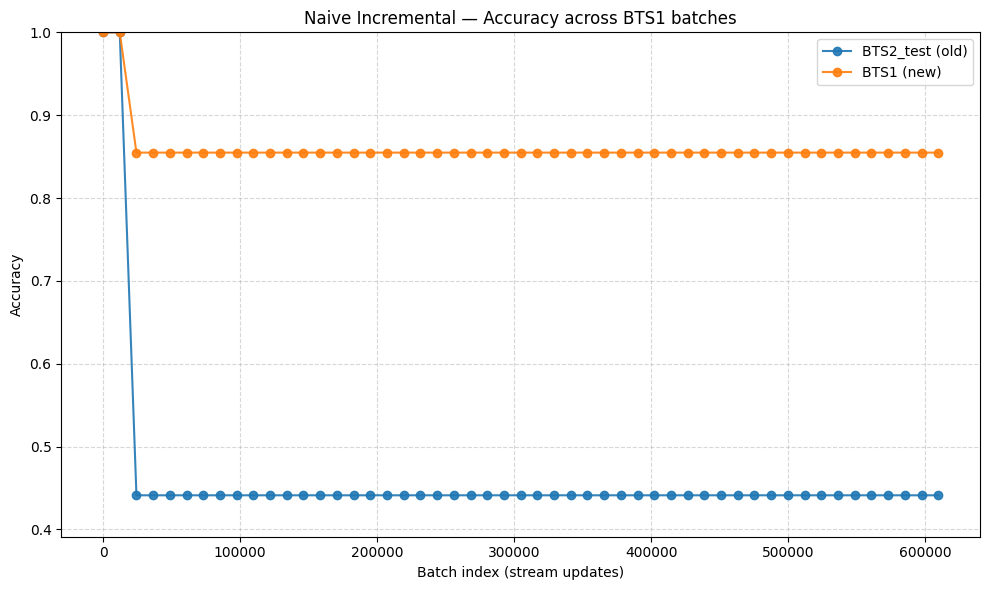

Saved forgetting curve: ../outputs/naive_forgetting_curve.png


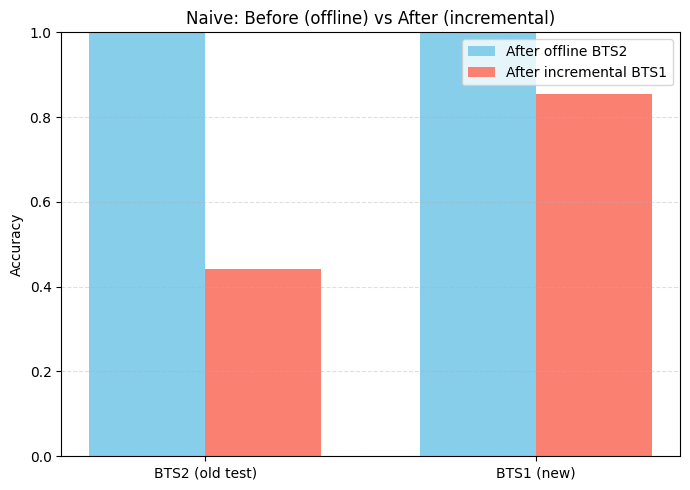

Saved before/after bar: ../outputs/naive_before_after.png


In [18]:
# CELL 9 - save model, CSV of batch accuracies, and plots
model_path = os.path.join(MODELS_DIR, "naive_incremental_model.pth")
torch.save(model.state_dict(), model_path)
print("Saved model:", model_path)

# Save batch-wise accuracies
acc_df = pd.DataFrame({
    "batch_idx": batch_idx,
    "acc_bts2_test": acc_old_batches,
    "acc_bts1": acc_new_batches
})
acc_csv = os.path.join(OUT_DIR, "naive_batch_accuracies.csv")
acc_df.to_csv(acc_csv, index=False)
print("Saved batch accuracies CSV:", acc_csv)

# Plot forgetting curve
plt.figure(figsize=(10,6))
plt.plot(batch_idx, acc_old_batches, '-o', label='BTS2_test (old)', alpha=0.9)
plt.plot(batch_idx, acc_new_batches, '-o', label='BTS1 (new)', alpha=0.9)
plt.xlabel("Batch index (stream updates)")
plt.ylabel("Accuracy")
plt.title("Naive Incremental — Accuracy across BTS1 batches")

min_acc = min(min(acc_old_batches), min(acc_new_batches))
y_min = max(0.0, min_acc - 0.05)

plt.ylim(y_min ,1)
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
curve_path = os.path.join(OUT_DIR, "naive_forgetting_curve.png")
plt.savefig(curve_path, dpi=200)
plt.show()
print("Saved forgetting curve:", curve_path)

# Plot before/after bar
plt.figure(figsize=(7,5))
labels = ['BTS2 (old test)', 'BTS1 (new)']
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, [acc_old_initial, acc_new_initial], width, label='After offline BTS2', color='skyblue')
plt.bar(x + width/2, [acc_old_after, acc_new_after], width, label='After incremental BTS1', color='salmon')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Naive: Before (offline) vs After (incremental)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
bar_path = os.path.join(OUT_DIR, "naive_before_after.png")
plt.savefig(bar_path, dpi=200)
plt.show()
print("Saved before/after bar:", bar_path)
